In [3]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 구글 드라이브 마운트
drive.mount('/content/drive')

# 출력 시 소수점 깔끔하게 설정
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

Mounted at /content/drive


In [5]:
import pandas as pd

# 1. 스크린샷에 확인된 정확한 절대 경로
exact_path = "/content/drive/MyDrive/kv_pca_loki_style_results/run_20260528_084747/aggregated_overall_summary_minimal.csv"

try:
    # 2. 데이터 강제 로드
    df = pd.read_csv(exact_path)
    print(f"✅ 파일을 성공적으로 불러왔습니다!")
    print(f"📊 총 로드된 데이터 행(Row) 수: {len(df)}")

    # 3. 🚨 파일에 eval_label이 없으므로, 파라미터 조합으로 직접 예쁜 라벨을 만들어줍니다!
    if 'eval_label' not in df.columns:
        def make_label(row):
            method = str(row.get('method', ''))

            if method == 'full_attention':
                return 'Full Attention'

            elif method == 'fixed_recent_window_attention':
                w = row.get('window_size', '-')
                return f"Recent W={w}"

            elif method == 'loki_style_pca_topk':
                a = row.get('n_axes', '-')
                k = row.get('final_k', '-')
                return f"Loki A={a}, K={k}"

            elif method == 'pca_axis_sign_range_filter':
                a = row.get('n_axes', '-')
                r = row.get('opposite_include_ratio', '-')
                return f"Ours (Range) A={a}, r={r}"

            elif method == 'pca_axis_sign_bucket_attention':
                a = row.get('n_axes', '-')
                r = row.get('opposite_include_ratio', '-')
                return f"Ours (Bucket) A={a}, r={r}"

            return method

        df['eval_label'] = df.apply(make_label, axis=1)

    # 4. 통합 비교용 핵심 컬럼 엄선 (🚨 하이퍼파라미터 컬럼 추가!)
    target_columns = [
        'eval_label', 'method',
        'n_axes', 'window_size', 'final_k', 'opposite_include_ratio', # <- 살려낸 파라미터들

        # --- [품질 지표: Quality] ---
        'mass_recall_mean', 'output_cosine_mean',

        # --- [하드웨어 효율: Ops & Memory] ---
        'page_read_ratio_mean', 'decode_macs_ratio_vs_full_mean',

        # --- [실제 속도: Latency] ---
        'attention_n_token_avg_latency_ms_mean',
        'attention_n_token_avg_latency_ratio_vs_full_mean'
    ]

    available_cols = [col for col in target_columns if col in df.columns]
    summary_df = df[available_cols].copy()

    # 정렬 (메서드와 파라미터 순서대로 예쁘게)
    sort_cols = [c for c in ['method', 'n_axes', 'window_size', 'final_k', 'opposite_include_ratio'] if c in available_cols]
    if sort_cols:
        summary_df = summary_df.sort_values(by=sort_cols).reset_index(drop=True)

    print("\n=========================================================================")
    print("🏆 [논문 통합 성적표] 모델 및 하이퍼파라미터 완벽 비교표")
    print("=========================================================================\n")

    # 보기 싫은 결측치(NaN)는 '-'로 깔끔하게 처리
    summary_df = summary_df.fillna('-')

    with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_columns', None, 'display.width', 1000):
        display(summary_df)

except FileNotFoundError:
    print("⚠️ 에러: 파일을 찾을 수 없습니다! 경로를 다시 한 번 확인해 주세요.")

✅ 파일을 성공적으로 불러왔습니다!
📊 총 로드된 데이터 행(Row) 수: 42

🏆 [논문 통합 성적표] 모델 및 하이퍼파라미터 완벽 비교표



,eval_label,method,n_axes,window_size,final_k,opposite_include_ratio,mass_recall_mean,output_cosine_mean,page_read_ratio_mean,decode_macs_ratio_vs_full_mean,attention_n_token_avg_latency_ms_mean,attention_n_token_avg_latency_ratio_vs_full_mean
0,Recent W=512.0,fixed_recent_window_attention,-,512.0000,512.0000,-,0.3531,0.7158,0.2500,0.2500,0.0297,0.9663
1,Recent W=512.0,fixed_recent_window_attention,-,512.0000,512.0000,-,0.3000,0.7020,0.1250,0.1250,0.0296,0.9844
2,Recent W=512.0,fixed_recent_window_attention,-,512.0000,512.0000,-,0.3527,0.8156,0.0625,0.0625,0.0297,0.9199
3,Recent W=1024.0,fixed_recent_window_attention,-,1024.0000,1024.0000,-,0.4115,0.7218,0.5000,0.5000,0.0296,0.9618
4,Recent W=1024.0,fixed_recent_window_attention,-,1024.0000,1024.0000,-,0.3264,0.7080,0.2500,0.2500,0.0294,0.9806
5,Recent W=1024.0,fixed_recent_window_attention,-,1024.0000,1024.0000,-,0.3843,0.8199,0.1250,0.1250,0.0293,0.9091
6,Recent W=2048.0,fixed_recent_window_attention,-,2048.0000,2048.0000,-,1.0000,1.0000,1.0000,1.0000,0.0332,1.0783
7,Recent W=2048.0,fixed_recent_window_attention,-,2048.0000,2048.0000,-,0.3700,0.7097,0.5000,0.5000,0.0329,1.0950
8,Recent W=2048.0,fixed_recent_window_attention,-,2048.0000,2048.0000,-,0.4313,0.8201,0.2500,0.2500,0.0327,1.0146
9,Full Attention,full_attention,-,2048.0000,2048.0000,-,1.0000,1.0000,1.0000,1.0000,0.0308,1.0000


/tmp/ipykernel_1728/994864898.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


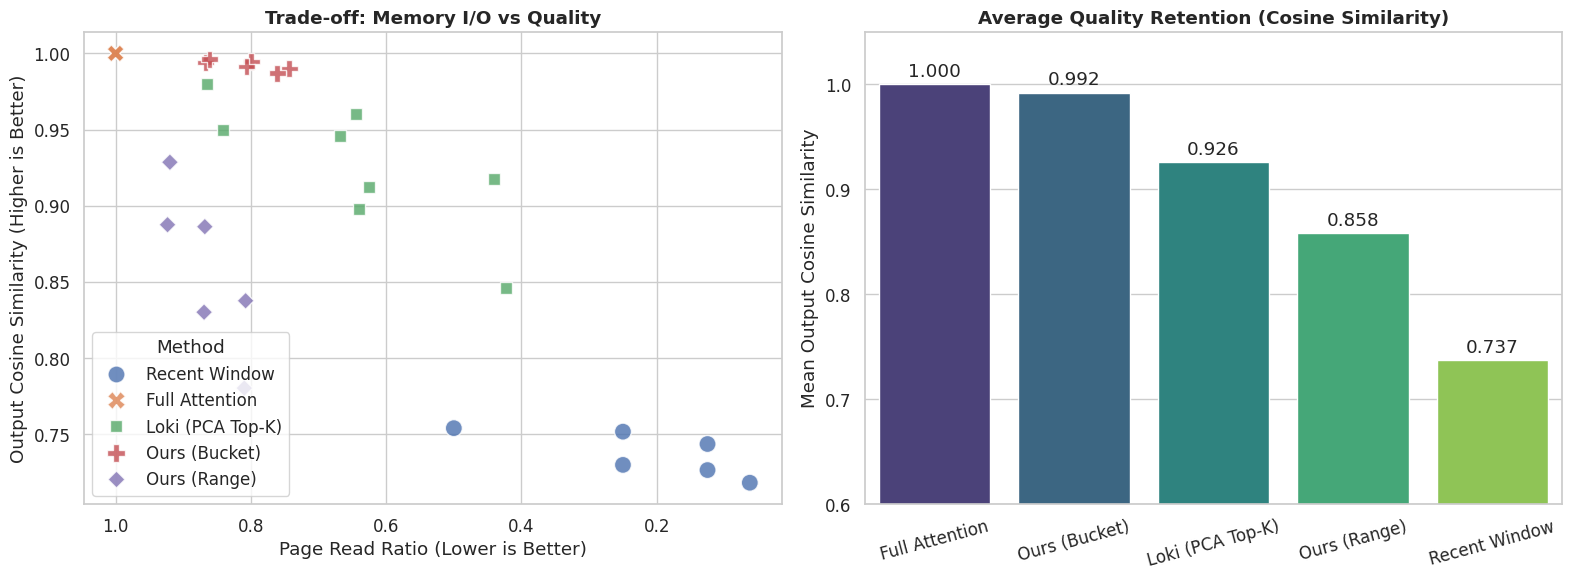

In [3]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 올려주신 데이터 (복붙하기 쉽게 문자열로 처리)
csv_data = """method,mass_recall_mean,output_cosine_mean,page_read_ratio_mean,decode_macs_ratio_vs_full_mean,attention_n_token_avg_latency_ms_mean,attention_n_token_avg_latency_ratio_vs_full_mean
fixed_recent_window_attention,0.3088,0.7437,0.1250,0.1250,0.0288,0.9913
fixed_recent_window_attention,0.3484,0.7518,0.2500,0.2500,0.0287,0.9850
fixed_recent_window_attention,0.3918,0.7541,0.5000,0.5000,0.0325,1.1179
fixed_recent_window_attention,0.3512,0.7300,0.2500,0.2500,0.0325,1.0424
fixed_recent_window_attention,0.2871,0.7183,0.0625,0.0625,0.0288,0.9236
fixed_recent_window_attention,0.3208,0.7266,0.1250,0.1250,0.0285,0.9142
full_attention,1.0000,1.0000,1.0000,1.0000,0.0291,1.0000
full_attention,1.0000,1.0000,1.0000,1.0000,0.0312,1.0000
loki_style_pca_topk,0.8197,0.8978,0.6396,0.2539,0.1903,6.5408
loki_style_pca_topk,0.8880,0.9500,0.8414,0.3789,0.1918,6.5899
loki_style_pca_topk,0.8799,0.9456,0.6680,0.3828,0.1900,6.5291
loki_style_pca_topk,0.9382,0.9801,0.8645,0.5078,0.1914,6.5791
loki_style_pca_topk,0.8582,0.9177,0.4406,0.3164,0.2022,6.4778
loki_style_pca_topk,0.8508,0.9122,0.6252,0.2520,0.2025,6.4863
loki_style_pca_topk,0.7798,0.8459,0.4223,0.1895,0.2028,6.4962
loki_style_pca_topk,0.9118,0.9605,0.6442,0.3789,0.2021,6.4741
pca_axis_sign_bucket_attention,0.9537,0.9900,0.7434,0.7433,0.4475,14.3361
pca_axis_sign_bucket_attention,0.9667,0.9947,0.7998,0.7999,0.4464,14.2987
pca_axis_sign_bucket_attention,0.9589,0.9914,0.8066,0.8068,0.4353,14.9605
pca_axis_sign_bucket_attention,0.9716,0.9940,0.8672,0.8674,0.4385,15.0684
pca_axis_sign_bucket_attention,0.9463,0.9871,0.7610,0.7609,0.4386,15.0740
pca_axis_sign_bucket_attention,0.9761,0.9962,0.8611,0.8612,0.4482,14.3581
pca_axis_sign_range_filter,0.8907,0.9286,0.9197,0.5530,0.2944,9.4297
pca_axis_sign_range_filter,0.7557,0.7804,0.8097,0.3077,0.2239,7.6949
pca_axis_sign_range_filter,0.7987,0.8302,0.8692,0.4111,0.2230,7.6627
pca_axis_sign_range_filter,0.8527,0.8876,0.9232,0.5507,0.2372,8.1504
pca_axis_sign_range_filter,0.8436,0.8863,0.8681,0.4131,0.2886,9.2455
pca_axis_sign_range_filter,0.7976,0.8377,0.8078,0.3085,0.2767,8.8648"""

df = pd.read_csv(io.StringIO(csv_data))

# 이름 예쁘게 매핑 (논문용)
method_map = {
    'full_attention': 'Full Attention',
    'fixed_recent_window_attention': 'Recent Window',
    'loki_style_pca_topk': 'Loki (PCA Top-K)',
    'pca_axis_sign_bucket_attention': 'Ours (Bucket)',
    'pca_axis_sign_range_filter': 'Ours (Range)'
}
df['method_clean'] = df['method'].map(method_map)

# 시각화 세팅
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# [Plot 1] Pareto Frontier: Memory I/O vs Quality
# (X축: Page Read Ratio (낮을수록 좋음), Y축: Cosine (높을수록 좋음))
# ---------------------------------------------------------
sns.scatterplot(
    data=df,
    x='page_read_ratio_mean',
    y='output_cosine_mean',
    hue='method_clean',
    style='method_clean',
    s=150,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title('Trade-off: Memory I/O vs Quality', fontweight='bold')
axes[0].set_xlabel('Page Read Ratio (Lower is Better)')
axes[0].set_ylabel('Output Cosine Similarity (Higher is Better)')
axes[0].invert_xaxis() # X축을 뒤집어서 우상단이 '최고 효율'이 되도록 만듦
axes[0].legend(title='Method', loc='lower left')

# ---------------------------------------------------------
# [Plot 2] Bar Chart: Average Quality (Cosine Similarity)
# ---------------------------------------------------------
# 그룹별 평균 계산
agg_df = df.groupby('method_clean')['output_cosine_mean'].mean().reset_index()
agg_df = agg_df.sort_values('output_cosine_mean', ascending=False)

sns.barplot(
    data=agg_df,
    x='method_clean',
    y='output_cosine_mean',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Average Quality Retention (Cosine Similarity)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Output Cosine Similarity')
axes[1].set_ylim(0.6, 1.05) # 편차를 잘 보여주기 위해 Y축 제한
axes[1].tick_params(axis='x', rotation=15)

# 값 표시
for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.3f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1728/90039526.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_1728/90039526.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


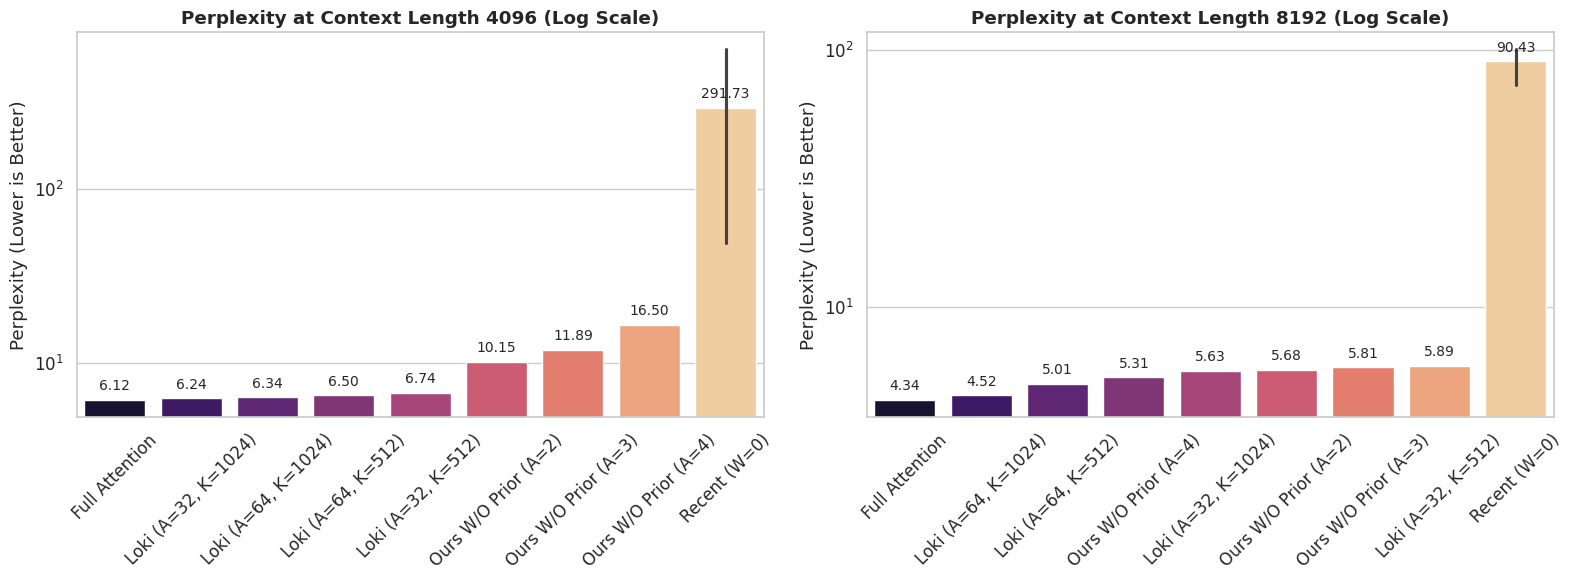

In [4]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 제공해주신 데이터 로드
csv_data = """method_name	model_variant	method	context_length	n_axes	final_k	window_size	recent_token_window	opposite_include_ratio	n_samples	mean_nll	std_nll	median_nll	max_nll	p90_nll	perplexity
sparse_full_attention	sparse_all_layers	full_attention	4096				0		35	1.810793442	2.064288078	1.169733405	8.632864952	4.614361572	6.115297643
sparse_full_attention	sparse_all_layers	full_attention	8192				0		35	1.468528257	1.667275245	1.009867549	5.652231216	3.826457405	4.342838894
sparse_loki_A32_K1024	sparse_all_layers	loki_style_pca_topk	4096	32	1024		0		35	1.831158547	2.131129706	1.154212952	9.043455124	4.936631393	6.241113094
sparse_loki_A32_K1024	sparse_all_layers	loki_style_pca_topk	8192	32	1024		0		35	1.727995831	1.848349627	1.185270786	6.266539574	4.965895271	5.629360406
sparse_loki_A32_K512	sparse_all_layers	loki_style_pca_topk	4096	32	512		0		35	1.907693054	2.182990966	1.1050843	9.431446075	4.595233536	6.737527746
sparse_loki_A32_K512	sparse_all_layers	loki_style_pca_topk	8192	32	512		0		35	1.773266429	1.83643785	1.109711051	6.992019653	4.594610596	5.89006144
sparse_loki_A64_K1024	sparse_all_layers	loki_style_pca_topk	4096	64	1024		0		35	1.8466979	2.138056141	1.154565096	8.7137537	4.941439247	6.338853397
sparse_loki_A64_K1024	sparse_all_layers	loki_style_pca_topk	8192	64	1024		0		35	1.508516822	1.735027538	0.9405700564	6.127572536	3.82394743	4.520021823
sparse_loki_A64_K512	sparse_all_layers	loki_style_pca_topk	4096	64	512		0		35	1.871963349	2.181663512	1.135598898	9.080962181	4.877835178	6.501047702
sparse_loki_A64_K512	sparse_all_layers	loki_style_pca_topk	8192	64	512		0		35	1.611963676	1.816511901	1.160772204	6.219258785	4.646685982	5.012644782
sparse_recent_W1024	sparse_all_layers	fixed_recent_window_attention	4096			1024	0		35	5.264774957	4.344757457	4.237067699	15.31714439	11.46724205	193.40278
sparse_recent_W1024	sparse_all_layers	fixed_recent_window_attention	8192			1024	0		35	4.608639859	4.15369681	3.429727793	15.62113285	10.75902462	100.3475699
sparse_recent_W2048	sparse_all_layers	fixed_recent_window_attention	4096			2048	0		35	3.885105875	4.113311915	2.294340134	14.93915462	10.0324976	48.67209533
sparse_recent_W2048	sparse_all_layers	fixed_recent_window_attention	8192			2048	0		35	4.28664793	3.90552915	2.881253719	14.39317989	10.30285034	72.72228928
sparse_recent_W512	sparse_all_layers	fixed_recent_window_attention	4096			512	0		35	6.450658369	4.858671533	5.308909416	17.28920746	14.61386852	633.1189819
sparse_recent_W512	sparse_all_layers	fixed_recent_window_attention	8192			512	0		35	4.58706993	4.306368838	3.089556456	15.47180176	10.92574711	98.20625697
sparse_sign_A2_r0.75	sparse_all_layers	pca_axis_sign_range_filter	4096	2			0	0.75	35	2.317016138	2.446148824	1.347009301	8.856877327	5.831364441	10.14535675
sparse_sign_A2_r0.75	sparse_all_layers	pca_axis_sign_range_filter	8192	2			0	0.75	35	1.737774905	1.901889041	0.9466667175	6.439957619	4.492437553	5.684680388
sparse_sign_A3_r0.75	sparse_all_layers	pca_axis_sign_range_filter	4096	3			0	0.75	35	2.476098777	2.605930817	1.334053278	8.627498627	6.47390337	11.89476963
sparse_sign_A3_r0.75	sparse_all_layers	pca_axis_sign_range_filter	8192	3			0	0.75	35	1.75923841	1.764268083	1.219424129	5.426818371	4.569690514	5.808012385
sparse_sign_A4_r0.75	sparse_all_layers	pca_axis_sign_range_filter	4096	4			0	0.75	35	2.803292947	2.918561679	1.871904135	10.54570198	7.356095123	16.49888738
sparse_sign_A4_r0.75	sparse_all_layers	pca_axis_sign_range_filter	8192	4			0	0.75	35	1.669505657	1.689962304	1.021963596	6.271605015	4.209015656	5.309542414"""

df = pd.read_csv(io.StringIO(csv_data), sep='\t')

# 2. 논문에 넣기 좋게 라벨 정리
def clean_method_name(row):
    if row['method'] == 'full_attention':
        return 'Full Attention'
    elif row['method'] == 'loki_style_pca_topk':
        return f"Loki (A={int(row['n_axes'])}, K={int(row['final_k'])})"
    elif row['method'] == 'fixed_recent_window_attention':
        return f"Recent (W={int(row['recent_token_window'])})"
    elif row['method'] == 'pca_axis_sign_range_filter':
        return f"Ours W/O Prior (A={int(row['n_axes'])})" # <- 🚨 핵심: W/O Prior (사전지식 없음) 강조!
    return row['method']

df['Method'] = df.apply(clean_method_name, axis=1)

# 3. 시각화 (Context Length 4096 & 8192 분리)
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, ctx in enumerate([4096, 8192]):
    ctx_df = df[df['context_length'] == ctx].sort_values('perplexity')

    ax = sns.barplot(
        data=ctx_df,
        x='Method',
        y='perplexity',
        palette='magma',
        ax=axes[i]
    )

    # Recent window 값이 너무 커서 Y축을 로그 스케일로 설정!
    axes[i].set_yscale('log')
    axes[i].set_title(f'Perplexity at Context Length {ctx} (Log Scale)', fontweight='bold')
    axes[i].set_ylabel('Perplexity (Lower is Better)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

    # 텍스트 라벨 (로그 스케일이므로 위치 미세조정)
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 데이터 세팅 (추출 완료)
# ==========================================
# X축 라벨과 등간격 설정을 위한 인덱스 배열
x_labels = ["2K", "4K", "8K", "12K", "32K", "64K", "96K"]
x = np.arange(len(x_labels)) # [0, 1, 2, 3, 4, 5, 6] -> 등간격 보장!

# (a) Mass Recall (Quality Defense)
recall_full       = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
recall_loki_32    = [0.9517, 0.8725, 0.8554, 0.7733, 0.7351, 0.5650, 0.3903]
recall_loki_64    = [0.9742, 0.9266, 0.9162, 0.8595, 0.8314, 0.7173, 0.5610]
recall_ours_range = [0.8493, 0.8358, 0.9034, 0.8563, 0.8960, 0.9165, 0.8648]
recall_ours_bucket= [0.9482, 0.9385, 0.9724, 0.9654, 0.8960, 0.9165, 0.8648]

# (b) Page Read Ratio (Memory Efficiency)
page_full       = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
page_loki_32    = [0.9729, 0.8299, 0.5863, 0.4819, 0.2186, 0.1016, 0.0705]
page_loki_64    = [0.9764, 0.8530, 0.5951, 0.4950, 0.2149, 0.1034, 0.0724]
page_ours_range = [0.9289, 0.9215, 0.9179, 0.9224, 0.9077, 0.8971, 0.8904]
page_ours_bucket= [0.8193, 0.7454, 0.7456, 0.7657, 0.9077, 0.8971, 0.8904]

# (c) Avg Token Latency ms (End-to-End Latency)
lat_full        = [0.0308, 0.0311, 0.0323, 0.0308, 0.0982, 0.0941, 0.1015]
lat_loki_32     = [0.1944, 0.1953, 0.2065, 0.2118, 0.3854, 0.3908, 0.3840]
lat_loki_64     = [0.1937, 0.1947, 0.2060, 0.2114, 0.3803, 0.3900, 0.3682]
lat_ours_range  = [0.2303, 0.2459, 0.3014, 0.2901, 0.4484, 0.4409, 0.4372]
lat_ours_bucket = [0.3949, 0.4551, 0.4656, 0.4487, 0.1705, 0.1746, 0.1803] # <- 크로스오버 핵심 구간!

# (d) MACs Ratio vs Full (Compute Efficiency)
macs_full       = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
macs_loki_32    = [0.6328, 0.3789, 0.2520, 0.2096, 0.1567, 0.1409, 0.1356]
macs_loki_64    = [0.7656, 0.5078, 0.3789, 0.3359, 0.2822, 0.2661, 0.2607]
macs_ours_range = [0.5570, 0.5504, 0.5526, 0.5535, 0.5530, 0.5573, 0.5577]
macs_ours_bucket= [0.8192, 0.7453, 0.7456, 0.7658, 0.5530, 0.5573, 0.5577]

# ==========================================
# 2. 전역 스타일 설정 (탑티어 학회용 디자인)
# ==========================================
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'lines.linewidth': 2.5,
    'lines.markersize': 8,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--'
})

# 공통 선 스타일 정의
style_full  = {'marker': 'None', 'linestyle': '-', 'color': '#7F8C8D', 'label': 'Full Attention'}
style_l32   = {'marker': 'o', 'linestyle': '--', 'color': '#F39C12', 'label': 'Loki (A=32, K=1K)'}
style_l64   = {'marker': '^', 'linestyle': '--', 'color': '#E74C3C', 'label': 'Loki (A=64, K=1K)'}
style_range = {'marker': 'D', 'linestyle': '-',  'color': '#9B59B6', 'label': 'Ours (Range)'}
style_bucket= {'marker': 's', 'linestyle': '-',  'color': '#1F77B4', 'label': 'Ours (Bucket)', 'linewidth': 3.5}

# ==========================================
# 3. 그래프 생성 및 저장 함수
# ==========================================
def plot_and_save(ylabel, data_full, data_l32, data_l64, data_rng, data_bkt, filename, loc='best'):
    fig, ax = plt.subplots(figsize=(6, 4.5))

    # x가 등간격 인덱스 배열이므로 이를 기준으로 그립니다.
    ax.plot(x, data_full, **style_full)
    ax.plot(x, data_l32, **style_l32)
    ax.plot(x, data_l64, **style_l64)
    ax.plot(x, data_rng, **style_range)
    ax.plot(x, data_bkt, **style_bucket)

    # X축 설정: 인덱스(0,1,2..) 자리에 글자 라벨("2K","4K"...)을 붙입니다.
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel('Context Length (Tokens)')
    ax.set_ylabel(ylabel)

    ax.legend(loc=loc)
    plt.tight_layout()

    plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.close()
    print(f"✅ Generated: {filename}")

# ==========================================
# 4. 4종 플롯 실행
# ==========================================
# (a) Mass Recall
plot_and_save('Mass Recall', recall_full, recall_loki_32, recall_loki_64, recall_ours_range, recall_ours_bucket,
              'fig_quality_recall.pdf', loc='lower left')

# (b) Page Read Ratio
plot_and_save('Page Read Ratio (vs Full)', page_full, page_loki_32, page_loki_64, page_ours_range, page_ours_bucket,
              'fig_memory_page_read.pdf', loc='lower left')

# (c) End-to-End Latency
plot_and_save('Avg Token Latency (ms)', lat_full, lat_loki_32, lat_loki_64, lat_ours_range, lat_ours_bucket,
              'fig_latency_e2e.pdf', loc='lower left')

# (d) MACs Ratio
plot_and_save('MACs Ratio (vs Full)', macs_full, macs_loki_32, macs_loki_64, macs_ours_range, macs_ours_bucket,
              'fig_latency_compute.pdf', loc='lower left')

✅ Generated: fig_quality_recall.pdf
✅ Generated: fig_memory_page_read.pdf
✅ Generated: fig_latency_e2e.pdf
✅ Generated: fig_latency_compute.pdf
